# Feature Importance Analysis — EXMD 601 Project
## Research Question: What factors predict cardiovascular complications in diabetic patients?

This notebook trains Random Forest classifiers on two outcomes:
- **Outcome A**: Stroke OR Heart Failure OR CKD within 10 years
- **Outcome B**: ED visit within 1 year

For each outcome we report:
1. Feature importances (bar plot)
2. Classification report (precision, recall, F1, accuracy)
3. Confusion matrix
4. ROC curve with AUC

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

### 2. Load cleaned data

In [2]:
df = pd.read_csv('../data/cleaned_data.csv')
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nOutcome A distribution:\n{df['outcome_a'].value_counts()}")
print(f"\nOutcome B distribution:\n{df['outcome_b'].value_counts()}")
df.head()

Dataset: 50148 rows, 18 columns

Outcome A distribution:
outcome_a
0    35556
1    14592
Name: count, dtype: int64

Outcome B distribution:
outcome_b
0    44366
1     5782
Name: count, dtype: int64


,age,gender,hba1c,cholesterol,glucose,triglycerides,creatinine,has_hba1c,has_cholesterol,has_glucose,has_triglycerides,has_creatinine,has_mi_20y,encounter_inpatient,has_death_record,hospitalized,outcome_a,outcome_b
0,99.229454,0,7.1,3.34,8.1,1.61,81.8,0,0,0,0,0,0,0,1,1,0,0
1,95.305877,1,7.1,3.34,8.1,1.61,81.8,0,0,0,0,0,0,0,1,0,0,0
2,95.589399,1,7.1,3.34,8.1,1.61,81.8,0,0,0,0,0,0,0,1,0,0,0
3,96.255120,1,7.1,3.34,8.1,1.61,81.8,0,0,0,0,0,1,0,0,0,0,0
4,91.813218,1,7.1,3.34,8.1,1.61,81.8,0,0,0,0,0,0,0,0,1,1,1


### 3. Separate features and outcomes

In [3]:
# Feature matrix (all columns except outcomes)
feature_cols = [c for c in df.columns if c not in ['outcome_a', 'outcome_b']]
X = df[feature_cols]

y_a = df['outcome_a']
y_b = df['outcome_b']

print(f"Features ({len(feature_cols)}): {feature_cols}")

Features (16): ['age', 'gender', 'hba1c', 'cholesterol', 'glucose', 'triglycerides', 'creatinine', 'has_hba1c', 'has_cholesterol', 'has_glucose', 'has_triglycerides', 'has_creatinine', 'has_mi_20y', 'encounter_inpatient', 'has_death_record', 'hospitalized']


### 4. Helper function for model evaluation

We define a reusable function that trains a Random Forest, evaluates it, and produces all required plots.

In [4]:
def evaluate_model(X, y, outcome_name, random_state=42):
    """
    Train a Random Forest classifier and display evaluation metrics.
    
    Parameters:
        X: feature matrix
        y: target variable
        outcome_name: string label for plots/titles
        random_state: seed for reproducibility
    
    Returns:
        model: trained RandomForestClassifier
        importances_df: DataFrame of feature importances
    """
    # --- Train/test split (80/20, stratified) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )
    print(f"Train set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")
    print(f"Train positive rate: {y_train.mean():.3f} | Test positive rate: {y_test.mean():.3f}")
    
    # --- Train Random Forest ---
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',  # handle class imbalance
        random_state=random_state,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    
    # --- Predictions ---
    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1]
    
    # --- 1. Classification Report ---
    print(f"\n{'='*60}")
    print(f"Classification Report — {outcome_name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
    
    # --- 2. Feature Importances (bar plot) ---
    importances = rf.feature_importances_
    importances_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': importances
    }).sort_values('importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(importances_df['feature'], importances_df['importance'], color='steelblue')
    ax.set_xlabel('Feature Importance (Gini)')
    ax.set_title(f'Feature Importances — {outcome_name}')
    plt.tight_layout()
    plt.show()
    
    # --- 3. Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {outcome_name}')
    plt.tight_layout()
    plt.show()
    
    # --- 4. ROC Curve ---
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {outcome_name}')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    
    print(f"\nAUC: {roc_auc:.3f}")
    
    return rf, importances_df

### 5. Outcome A: Stroke / Heart Failure / CKD within 10 years

OUTCOME A: Stroke / Heart Failure / CKD within 10 years
Train set: 40118 rows | Test set: 10030 rows
Train positive rate: 0.291 | Test positive rate: 0.291

Classification Report — Outcome A (Stroke/HF/CKD 10y)
              precision    recall  f1-score   support

    Negative       0.83      0.71      0.76      7111
    Positive       0.48      0.66      0.55      2919

    accuracy                           0.69     10030
   macro avg       0.66      0.68      0.66     10030
weighted avg       0.73      0.69      0.70     10030



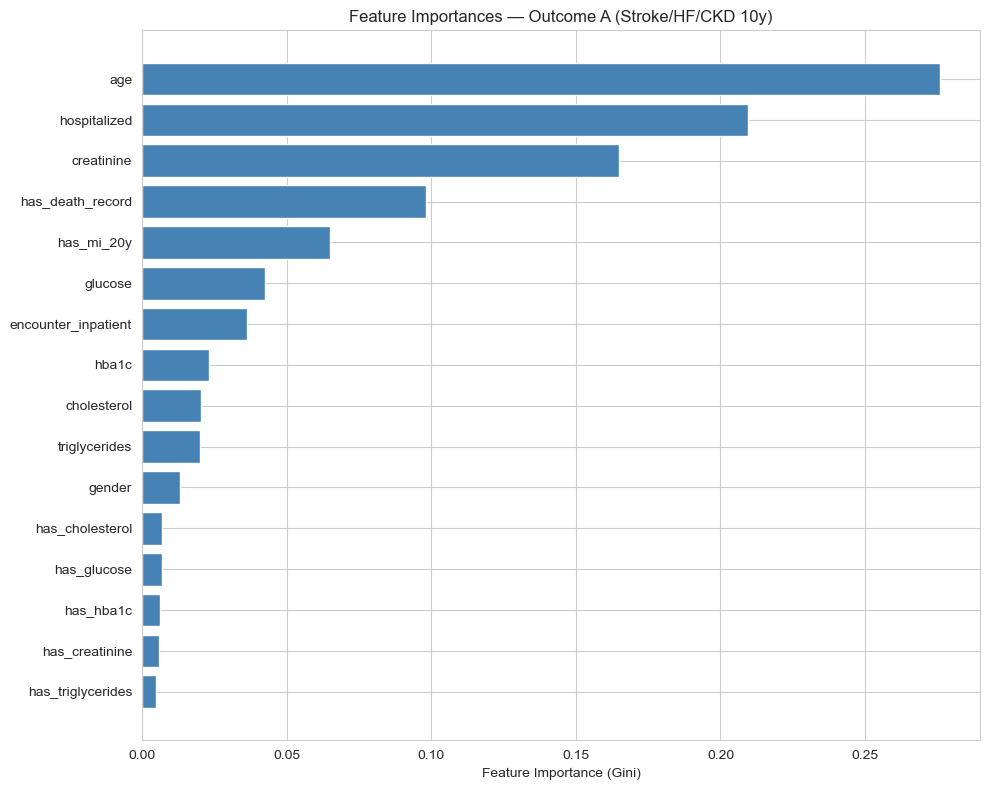

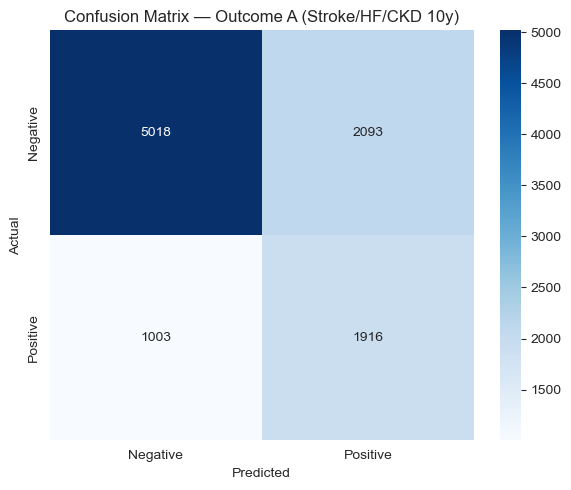

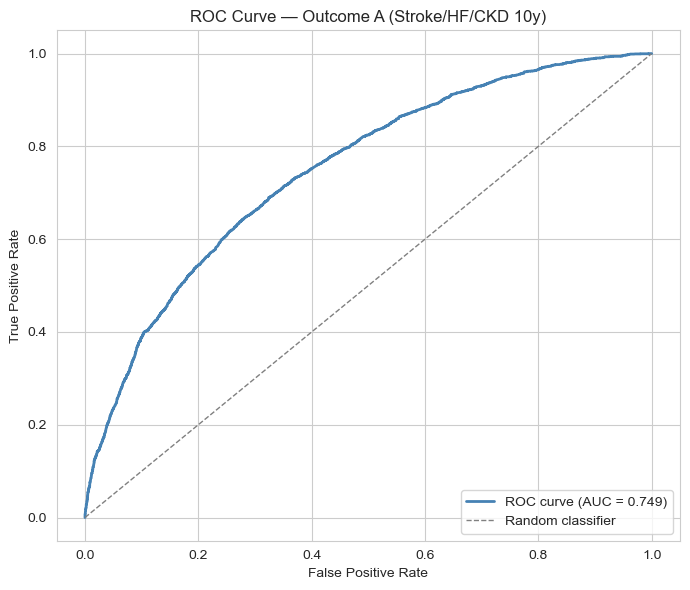


AUC: 0.749


In [5]:
print("=" * 60)
print("OUTCOME A: Stroke / Heart Failure / CKD within 10 years")
print("=" * 60)
rf_a, imp_a = evaluate_model(X, y_a, "Outcome A (Stroke/HF/CKD 10y)")

### 6. Outcome B: ED visit within 1 year

OUTCOME B: ED visit within 1 year
Train set: 40118 rows | Test set: 10030 rows
Train positive rate: 0.115 | Test positive rate: 0.115

Classification Report — Outcome B (ED visit 1y)
              precision    recall  f1-score   support

    Negative       0.99      0.66      0.79      8874
    Positive       0.26      0.93      0.41      1156

    accuracy                           0.69     10030
   macro avg       0.62      0.79      0.60     10030
weighted avg       0.90      0.69      0.75     10030



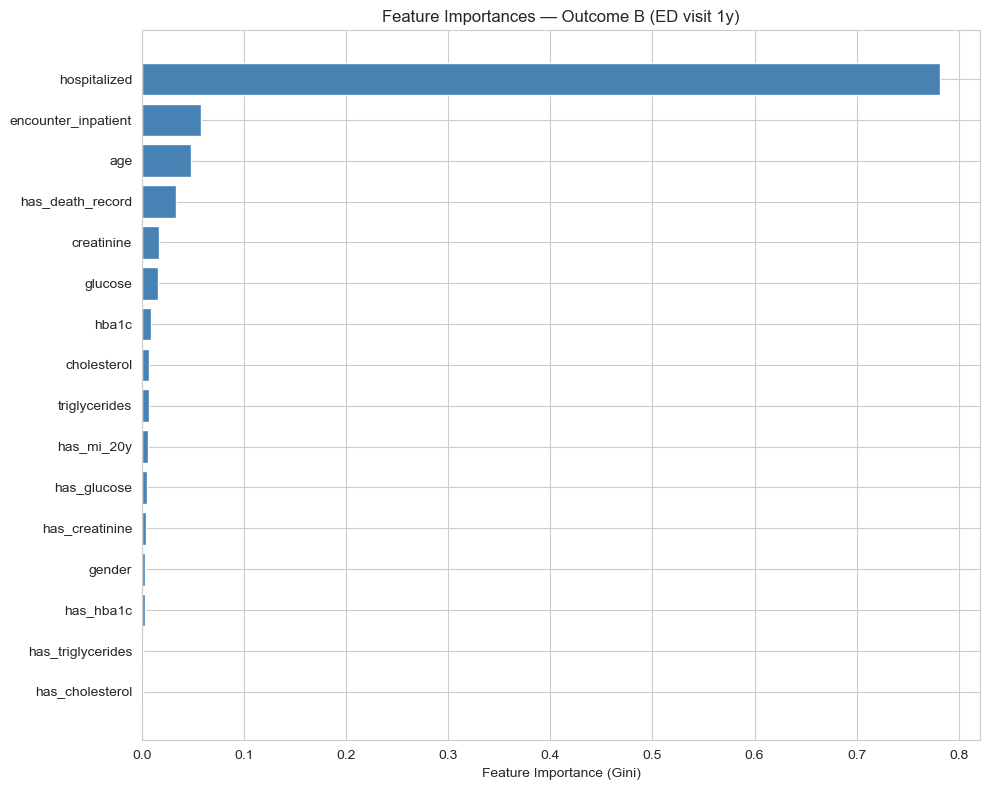

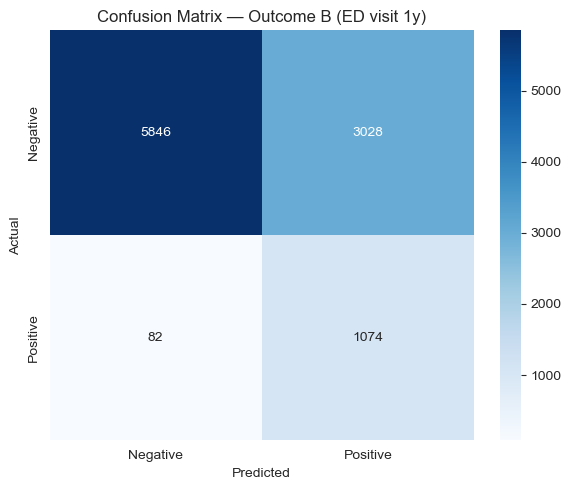

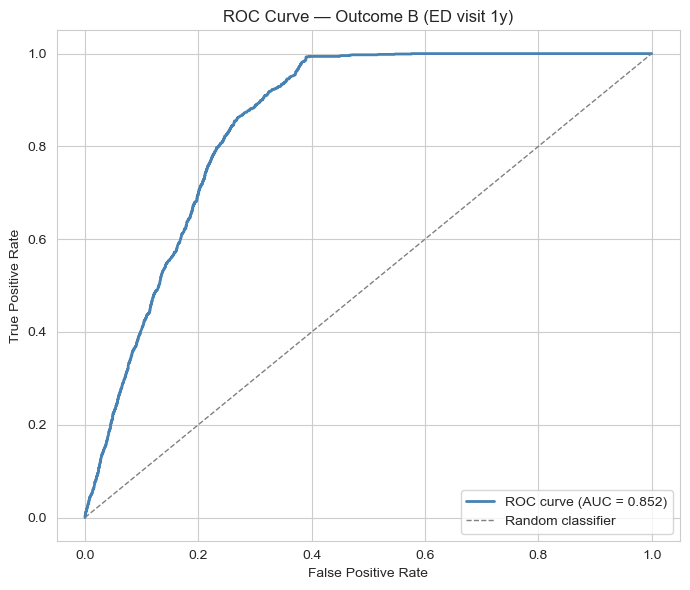


AUC: 0.852


In [6]:
print("=" * 60)
print("OUTCOME B: ED visit within 1 year")
print("=" * 60)
rf_b, imp_b = evaluate_model(X, y_b, "Outcome B (ED visit 1y)")

### 7. Summary: Top predictive features comparison

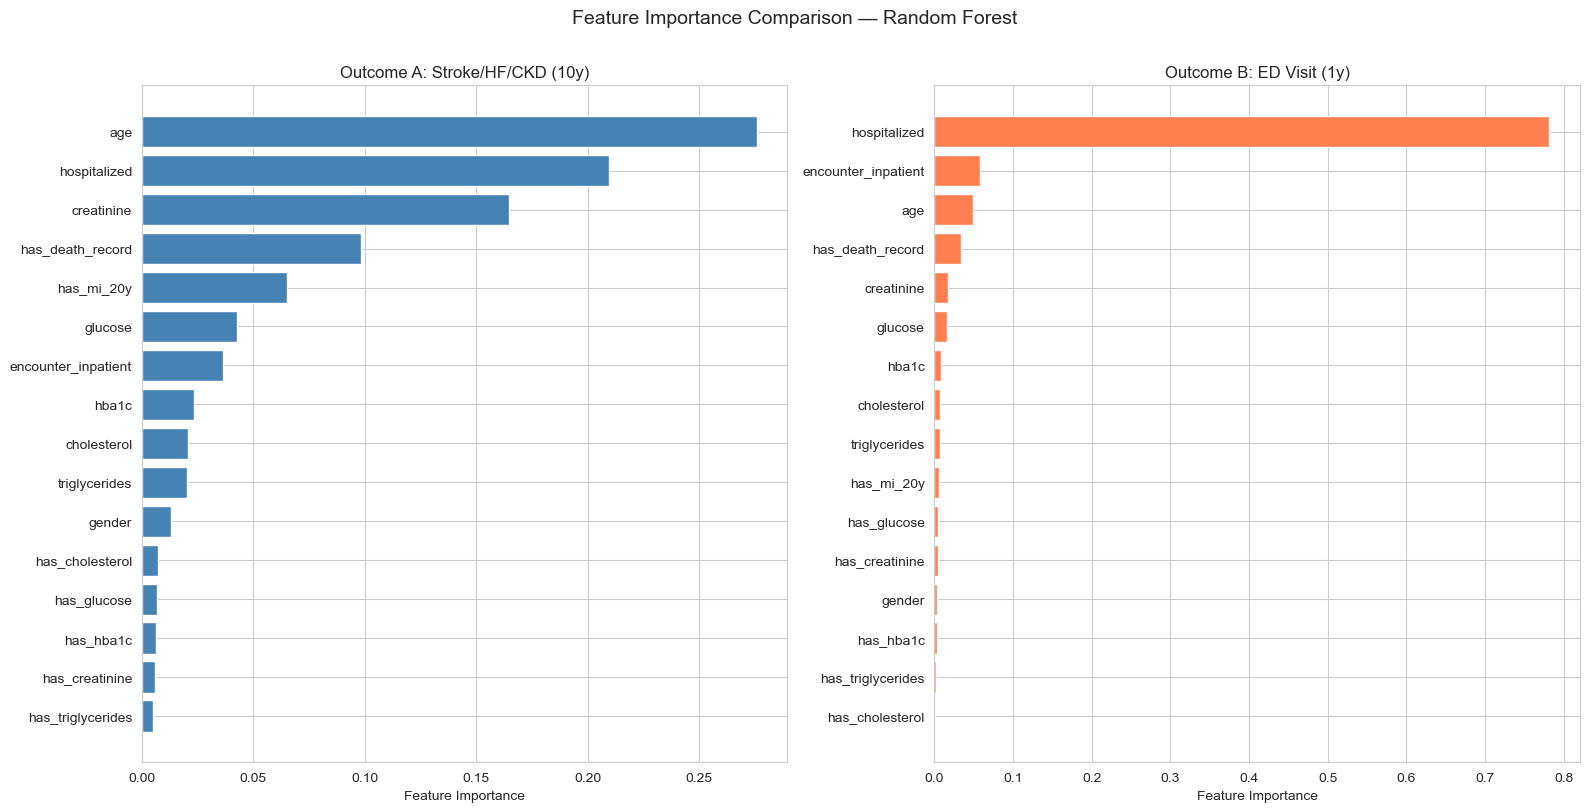


Top 5 features for Outcome A (Stroke/HF/CKD 10y):
  age: 0.2759
  hospitalized: 0.2094
  creatinine: 0.1648
  has_death_record: 0.0983
  has_mi_20y: 0.0649

Top 5 features for Outcome B (ED visit 1y):
  hospitalized: 0.7818
  encounter_inpatient: 0.0575
  age: 0.0484
  has_death_record: 0.0337
  creatinine: 0.0168


In [7]:
# Side-by-side comparison of top features for both outcomes
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Outcome A
imp_a_sorted = imp_a.sort_values('importance', ascending=True)
axes[0].barh(imp_a_sorted['feature'], imp_a_sorted['importance'], color='steelblue')
axes[0].set_title('Outcome A: Stroke/HF/CKD (10y)')
axes[0].set_xlabel('Feature Importance')

# Outcome B
imp_b_sorted = imp_b.sort_values('importance', ascending=True)
axes[1].barh(imp_b_sorted['feature'], imp_b_sorted['importance'], color='coral')
axes[1].set_title('Outcome B: ED Visit (1y)')
axes[1].set_xlabel('Feature Importance')

plt.suptitle('Feature Importance Comparison — Random Forest', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Print top 5 features for each outcome
print("\nTop 5 features for Outcome A (Stroke/HF/CKD 10y):")
for _, row in imp_a.sort_values('importance', ascending=False).head(5).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

print("\nTop 5 features for Outcome B (ED visit 1y):")
for _, row in imp_b.sort_values('importance', ascending=False).head(5).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

### 8. Discussion

**Methodology notes:**
- We used `class_weight='balanced'` in the Random Forest to handle class imbalance, which is expected since cardiovascular complications affect a minority of patients.
- Binary "has_lab_test" indicators were included alongside imputed lab values. This allows the model to distinguish between "the test was not ordered" vs "the test result was X" — an important clinical distinction, especially given the high missingness rates (70-93%).
- Homocysteine was excluded entirely due to near-100% missingness.
- We set `max_depth=10` to prevent overfitting on 50k+ samples while still capturing non-linear relationships.
- Features that could introduce data leakage were excluded: `has_death_record` (death could result from outcomes), `hospitalized` (post-reference hospitalization could be a consequence), and `has_mi_20y` (MI in the 20-year post-reference window could occur after the predicted outcomes).

**Limitations:**
- Median imputation for highly missing lab values is a simplification; the binary missingness indicators help mitigate this but do not fully resolve it.
- The synthetic nature of the MDClone data means effect sizes may not perfectly reflect real clinical relationships.
- The ED visit column (`e_30dPost_...`) has a misleading name suggesting 30-day data, but contains values beyond 30 days; we use it for 1-year ED visits based on the actual data values.
- A more thorough analysis could include hyperparameter tuning (GridSearchCV), cross-validation, and comparison with other models (gradient boosting).